# Boundary Suppression — Semifreddo + Ledidi (single example)

Optimises the central bin (index 256 in the 512-bin map, index 320 counting the
64-bin cropping offset) of a flat genomic region to produce a strong boundary.

**Key difference from full-sequence optimisation:** only the 11-bin padded sequence
slice around the edited bin is passed through the convolutional tower on each step;
all other activations are served from the pre-cached tower output.

```
center bin (in map) : 256
center bin (in 640) : 256 + 64 (cropping) = 320
sequence window     : bin 315–325 → (320-5)*2048 to (320+6)*2048 = 11 bins = 22 528 bp
bins replaced       : 318–322 (central 5)
```

## 1. Imports

Standard library and third-party imports, plus AkitaSF framework modules.
`helper.py` provides plot_history and make_ctcf_exclusion_mask utilities
shared across boundary design notebooks.

In [11]:
import ast
import os
import sys

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

from memelite import fimo

sys.path.append(os.path.abspath("/home1/smaruj/pytorch_akita/"))
sys.path.insert(0, "/home1/smaruj/ledidi/ledidi/")
sys.path.insert(0, os.path.abspath("/home1/smaruj/ledidi_akita/"))

from akita.model import SeqNN
from ledidi import Ledidi
from semifreddo.semifreddo import SemifreddoLedidiWrapper
from utils.data_utils import from_upper_triu
from utils.losses_utils import LocalL1Loss
from utils.fimo_utils import read_meme_pwm

from helper import make_ctcf_exclusion_mask, plot_history

## 2. Parameters

 All paths, bin coordinates, and hyperparameters are defined here.

Boundary suppression inverts the boundary design task: starting from a
sequence that was successfully optimised to produce a strong TAD boundary
(insulation score target = -0.5), we now optimise it back towards the
original genomic prediction (no boundary). The editable region is the
central 2048 bp bin (bin 256 in the 512-bin contact map, bin 320 in the
640-bin tower space after adding the 64-bin Akita cropping offset).

CTCF motifs ± CTCF_FLANK bp are frozen during optimisation to preserve
the CTCF binding sites introduced in the boundary design step.

In [3]:
# ── Sequence to optimise ─────────────────────────────────────────────────
FOLD  = 0
CHROM = "chr11"
START = 65660928
END   = 66971648

STEM  = f"{CHROM}_{START}_{END}"

MASK_DIR = (
    "/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/"
    "optimizations/feature_masks"
)
MASK_PATH = f"{MASK_DIR}/boundary_mask.pt"

SUPPRESSION_DIR = (
    "/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/"
    "optimizations/boundary_suppression"
)
MODEL_PATH = (
    "/home1/smaruj/pytorch_akita/models/finetuned/mouse/Hsieh2019_mESC/checkpoints/"
    "Akita_v2_mouse_Hsieh2019_mESC_model0_finetuned.pth"
)
SUCCESSFUL_OPT_TSV = (
    "/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/"
    "optimizations/boundaries/successful_optimizations_-0.5.tsv"
)

# Pre-generated by generate_boundary_suppression_files.py:
#   initial_sequences/  — boundary-optimised sequence (X_mod, boundary inserted)
#   initial_tower_outputs/ — cached Semifreddo tower activations of X_mod
#   targets/            — model prediction of the *unmodified* genomic sequence
SEQ_PATH    = f"{SUPPRESSION_DIR}/initial_sequences/fold{FOLD}/{STEM}_X.pt"
TOWER_PATH  = f"{SUPPRESSION_DIR}/initial_tower_outputs/fold{FOLD}/{STEM}_tower_out.pt"
TARGET_PATH = f"{SUPPRESSION_DIR}/targets/fold{FOLD}/{STEM}_target.pt"

PWM_PATH = "/home1/smaruj/ledidi_akita/data/pwm/MA0139.1.meme"

# ── Semifreddo bin coordinates ────────────────────────────────────────────────
CENTER_BIN_MAP = 256   # central bin in the 512-bin contact map
CENTER_BIN_640 = 320   # = CENTER_BIN_MAP + 64 (Akita cropping offset)
CONTEXT_BINS   = 5     # ±5 bins → 11-bin window → Pearson R = 1.0 vs full model
BIN_SIZE       = 2048  # bp per bin

# ── CTCF exclusion flank ──────────────────────────────────────────────────────
# Positions within ±CTCF_FLANK bp of each CTCF motif are frozen in Ledidi's
# input_mask, preventing the optimiser from disrupting CTCF binding sites.
CTCF_FLANK = 15        # bp to freeze on each side of a CTCF motif

# ── Optimisation hyperparameters ──────────────────────────────────────────────
L              = 0.01
MAX_ITER       = 2000
EARLY_STOPPING = 2000

# ── Visualisation ─────────────────────────────────────────────────────────────
VMIN, VMAX = -0.6, 0.6
CMAP       = 'RdBu_r'

## 3. Load Model

In [4]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = SeqNN()
model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
model.to(device).eval()
print("Model loaded")

Device: cuda:0
Model loaded


## 4. Load CTCF positions for this sequence
Retrieve the CTCF motif positions recorded during the boundary design step.
Positions are stored as a stringified list of (start, end) tuples, relative
to the start of the 2048 bp editable bin (0-indexed, end-exclusive).

In [5]:
df_opt = pd.read_csv(SUCCESSFUL_OPT_TSV, sep="\t")

row = df_opt[
    (df_opt["fold"] == FOLD) &
    (df_opt["chrom"] == CHROM) &
    (df_opt["centered_start"] == START) &
    (df_opt["centered_end"] == END)
].iloc[0]

# Parse stringified list of tuples, e.g. "[(127, 146), (1380, 1399)]"
ctcf_positions = ast.literal_eval(row["positions"])
print(f"CTCF motif positions (relative, within editable bin): {ctcf_positions}")

CTCF motif positions (relative, within editable bin): [(127, 146), (1380, 1399)]


## 5. Load Pre-generated Files
`X`      : boundary-optimised one-hot sequence (starting point for suppression)   
`tower`  : cached conv tower activations of `X` (used by Semifreddo)   
`target` : model prediction of the *unmodified* genomic sequence (optimisation target)   

In [6]:
X      = torch.load(SEQ_PATH,    weights_only=True).to(device)               # (1, 4, L)
tower  = torch.load(TOWER_PATH,  weights_only=True).to(device)               # (1, 128, 640)
target = torch.load(TARGET_PATH, weights_only=True).to(device)               # (1, 1, N_triu)

print(f"X shape      : {X.shape}")
print(f"Tower shape  : {tower.shape}")
print(f"Target shape : {target.shape}")

X shape      : torch.Size([1, 4, 1310720])
Tower shape  : torch.Size([1, 128, 640])
Target shape : torch.Size([1, 1, 130305])


## 6. Build Semifreddo wrapper and sanity check

The wrapper extracts the 11-bin padded sequence slice from `X` on every Ledidi step
and runs only that slice through the convolutional tower, splicing the result back
into the cached `tower` activations.

edited_bin is given in 512-bin contact-map space (256), not 640-bin space (320).
The wrapper handles the cropping offset internally.

Sanity check: Pearson R between full Akita and Semifreddo should be 1.0.

In [7]:
sf_wrapper = SemifreddoLedidiWrapper(
    model                   = model,
    precomputed_full_output = tower,
    full_X                  = X,
    edited_bin              = CENTER_BIN_MAP,   # 256, NOT 320
    context_bins            = CONTEXT_BINS,
    cropping_applied        = 64,
)

print(f"Sequence slice : bp {sf_wrapper.seq_slice_start:,} – {sf_wrapper.seq_slice_end:,}")
print(f"Center bin bp  : {sf_wrapper.center_bp_start:,} – {sf_wrapper.center_bp_end:,}")

# Sanity check — pass only the central bin
X_center = X[:, :, sf_wrapper.center_bp_start:sf_wrapper.center_bp_end]  # (1, 4, 2048)

with torch.no_grad():
    y_full = model(X)
    y_sf   = sf_wrapper(X_center)

r, _ = pearsonr(y_full.cpu().flatten().numpy(), y_sf.cpu().flatten().numpy())
print(f"\nSanity check — Pearson R (full vs Semifreddo): {r:.6f}  (expect 1.0)")

Sequence slice : bp 645,120 – 667,648
Center bin bp  : 655,360 – 657,408

Sanity check — Pearson R (full vs Semifreddo): 1.000000  (expect 1.0)


/home1/smaruj/miniconda3/envs/pytorch_hic/lib/python3.10/site-packages/torch/nn/modules/conv.py:306: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:84.)
  return F.conv1d(input, weight, bias, self.stride,


## 7. Build CTCF exclusion mask
Freeze CTCF motif positions ± CTCF_FLANK bp so the optimiser cannot disrupt
the binding sites. The mask has shape (2048,) matching `X_center`'s last dimension.
True = position is frozen (weight set to -inf in Ledidi).

In [8]:
input_mask = make_ctcf_exclusion_mask(ctcf_positions, flank=CTCF_FLANK)
print(f"Frozen positions: {input_mask.sum().item()} / {input_mask.shape[0]} bp")

Frozen positions: 98 / 2048 bp


## 8. Load boundary mask and build output loss
`LocalL1Loss` restricts the output loss to the inter-compartment quadrants of
the contact map (the upper-tri indices where a TAD boundary would manifest).
This focuses the gradient signal on the boundary region rather than the full map,
matching the loss structure used in the original boundary design step.

In [9]:
boundary_mask = torch.load(MASK_PATH, weights_only=True).to(device)
local_output_loss = LocalL1Loss(boundary_mask, n_triu=130305, reduction='sum').to(device)

## Cell 9 — Run optimisation
Ledidi minimises: output_loss(model(X_hat), target) + L * input_loss(X_hat, X)

`output_loss` : LocalL1Loss over boundary quadrant — drives the map towards the unmodified genomic prediction (no boundary)   
`input_loss`  : L1Loss — penalises the number of edits (regularisation)   
`input_mask`  : freezes CTCF motif positions ± flank   

With L=0.01 the output loss dominates, allowing more edits to fully suppress
the boundary.

In [10]:
ledidi_optimizer = Ledidi(
    sf_wrapper,
    shape              = X_center.shape[1:],          # (4, 2048)
    input_loss         = torch.nn.L1Loss(reduction='sum'),
    output_loss        = local_output_loss,
    input_mask          = input_mask,
    batch_size         = 1,
    l                  = L,
    max_iter           = MAX_ITER,
    early_stopping_iter = EARLY_STOPPING,
    return_history     = True,
    verbose            = True,
).cuda()

generated_seq, history = ledidi_optimizer.fit_transform(X_center, target)

iter=I	input_loss=0.0	output_loss=4.277e+04	total_loss=4.277e+04	time=0.0
iter=100	input_loss=658.0	output_loss=1.446e+04	total_loss=1.446e+04	time=7.657
iter=200	input_loss=783.0	output_loss=2.959e+03	total_loss=2.967e+03	time=7.498
iter=300	input_loss=812.0	output_loss=2.049e+03	total_loss=2.057e+03	time=7.499
iter=400	input_loss=810.0	output_loss=2.117e+03	total_loss=2.125e+03	time=7.507
iter=500	input_loss=813.0	output_loss=1.824e+03	total_loss=1.833e+03	time=7.591
iter=600	input_loss=811.0	output_loss=1.814e+03	total_loss=1.822e+03	time=7.508
iter=700	input_loss=813.0	output_loss=1.688e+03	total_loss=1.696e+03	time=7.492
iter=800	input_loss=814.0	output_loss=1.63e+03	total_loss=1.638e+03	time=7.503
iter=900	input_loss=810.0	output_loss=1.582e+03	total_loss=1.59e+03	time=7.585
iter=1000	input_loss=825.0	output_loss=1.547e+03	total_loss=1.555e+03	time=7.597
iter=1100	input_loss=811.0	output_loss=1.436e+03	total_loss=1.444e+03	time=7.594
iter=1200	input_loss=831.0	output_loss=1.5e+03

## 10. Reconstruct full sequence
Ledidi operates only on the 2048 bp editable bin. Splice the optimised bin
back into the full-length sequence for downstream model evaluation.

In [12]:
# Then reconstruct full sequence afterward
full_generated_seq = X.clone()
full_generated_seq[:, :, sf_wrapper.center_bp_start:sf_wrapper.center_bp_end] = generated_seq

## 11. Plot optimisation loss curves

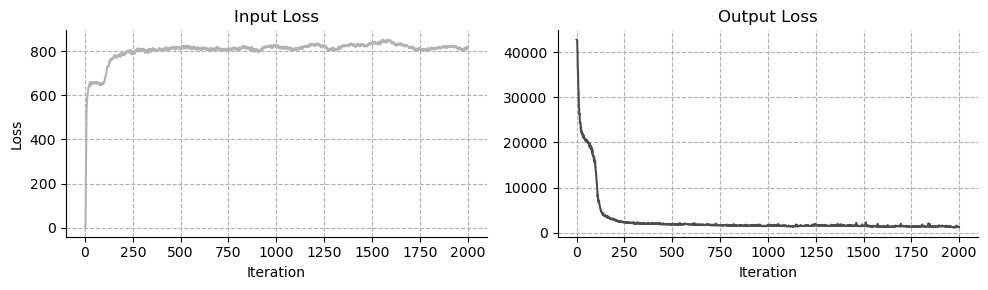

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].plot(history['input_loss'],  c='0.7')
axes[0].set_title('Input Loss')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss')
axes[0].grid(True, linestyle='--')

axes[1].plot(history['output_loss'], c='0.3')
axes[1].set_title('Output Loss')
axes[1].set_xlabel('Iteration')
axes[1].grid(True, linestyle='--')

sns.despine()
plt.tight_layout()
plt.show()

## 12. Count edits
Compare argmax of the generated vs. initial sequence across the full sequence
to count how many nucleotide positions were changed.

In [14]:
n_edits = (torch.argmax(full_generated_seq, dim=1) != torch.argmax(X, dim=1)).sum().item()
print(f"Number of edited nucleotides: {n_edits:,}")

Number of edited nucleotides: 807


## 13. Scan generated sequence for CTCF motifs (JASPAR MA0139.1)
Run FIMO on the optimised central bin to verify that CTCF motifs are intact
after suppression. These hits are passed to plot_history for visualisation.

In [15]:
pwm     = read_meme_pwm(PWM_PATH)
motifs  = {"CTCF": pwm}

edited_hits = fimo(motifs=motifs, sequences=generated_seq.cpu().detach().numpy(),
                               threshold=1e-4, reverse_complement=True)[0]

edited_hits

,motif_name,motif_idx,sequence_name,start,end,strand,score,p-value
0,CTCF,0,0,1204,1223,+,15.313542,3.044519e-06
1,CTCF,0,0,1559,1578,+,18.924778,2.676425e-07
2,CTCF,0,0,1721,1740,+,15.187717,3.430894e-06
3,CTCF,0,0,127,146,-,21.645960,2.557135e-08
4,CTCF,0,0,1380,1399,-,21.815586,2.100933e-08
5,CTCF,0,0,1499,1518,-,8.881119,8.324393e-05


## 14. Visualise edit history
Grey dots: positions edited at each iteration (alpha = batch edit frequency).   
Deep green shading: CTCF core motif positions (frozen).   
Light green shading: ±CTCF_FLANK bp flanks around each motif (frozen).   
Lower panel: CTCF motif orientations in the optimised sequence (blue = +, red = -).   

/home1/smaruj/ledidi_akita/optimizations/boundary_suppression/generation/helper.py:197: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


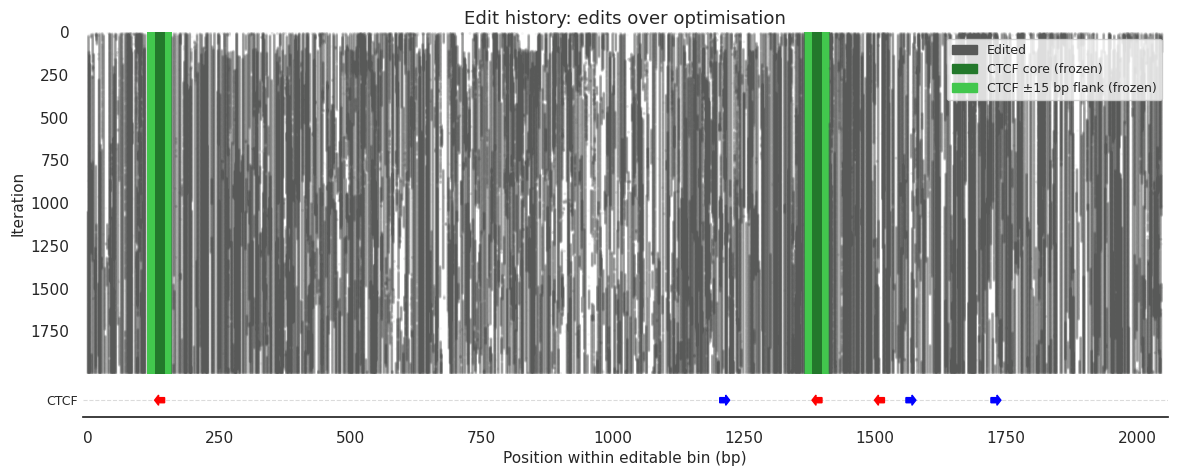

In [16]:
fig, axes = plot_history(
    history,
    ctcf_positions=ctcf_positions,
    ctcf_hits=edited_hits,
    ctcf_flank=CTCF_FLANK,
)

## 15. Evaluate optimisation quality
Pearson R between the optimised prediction and the target (unmodified genomic
prediction) quantifies how well the suppression succeeded.
Pearson R of the initial (boundary) sequence vs. the same target is shown
as a baseline — a lower R means the boundary was further from the target.

In [17]:
model.eval()
with torch.no_grad():
    pred_optimised = model(full_generated_seq)
    pred_initial   = model(X)

r_opt, _ = pearsonr(
    pred_optimised.cpu().flatten().numpy(),
    target.cpu().flatten().numpy(),
)
r_init, _ = pearsonr(
    pred_initial.cpu().flatten().numpy(),
    target.cpu().flatten().numpy(),
)
print(f"Pearson R (optimised vs target) : {r_opt:.4f}")
print(f"Pearson R (initial   vs target) : {r_init:.4f}")

Pearson R (optimised vs target) : 0.9958
Pearson R (initial   vs target) : -0.0148


## 16. Visualise contact maps
Three panels side by side:
   `Initial`  : prediction of the boundary-optimised starting sequence
   `Target`   : prediction of the original unmodified genomic sequence
   `Optimised`: prediction of the suppression-optimised sequence

A successful suppression result will show the Optimised map closely
matching the Target, with the inter-compartment signal reduced relative
to the Initial map.

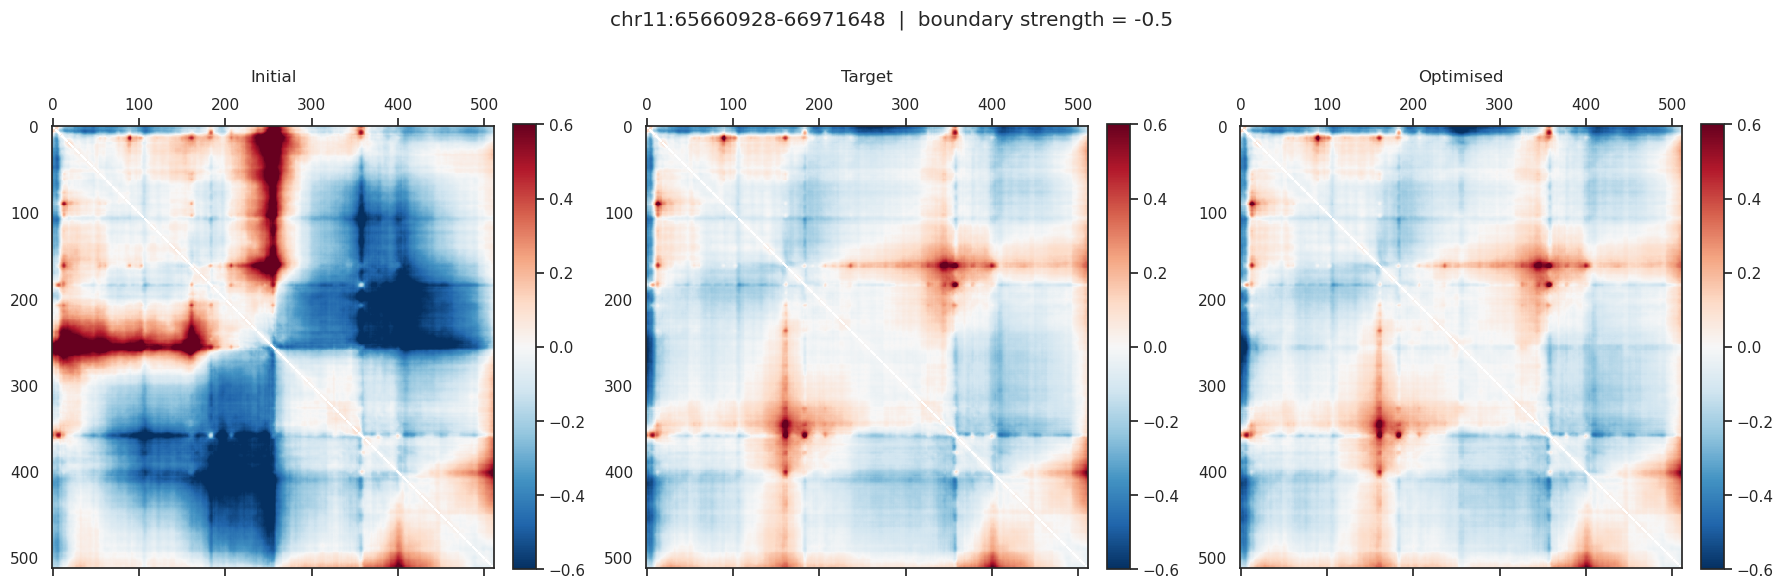

In [18]:
mat_initial   = from_upper_triu(pred_initial[0, 0, :],   matrix_len=512, num_diags=2)
mat_optimised = from_upper_triu(pred_optimised[0, 0, :],  matrix_len=512, num_diags=2)
mat_target    = from_upper_triu(target[0, 0, :],          matrix_len=512, num_diags=2)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
titles = ['Initial', 'Target', 'Optimised']
matrices = [mat_initial, mat_target, mat_optimised]

for ax, mat, title in zip(axes, matrices, titles):
    im = ax.matshow(mat.astype(np.float32), cmap=CMAP, vmin=VMIN, vmax=VMAX)
    ax.set_title(title, pad=12)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(f"{CHROM}:{START}-{END}  |  boundary strength = -0.5", y=1.02)
plt.tight_layout()
# plt.savefig(f"./../plots/boundary_suppression_sf_{STEM}.svg", format='svg', bbox_inches='tight')
plt.show()